# Making a Filterfile for generating simulated 2-channel PPD data

### Imports

In [1]:
from detprocess import Noise, Template
import numpy as np
import matplotlib.pyplot as plt
import cloudpickle

def twopole(t, trise, tfall, A, t0):
    thing = A * ( np.exp(-(t-t0)/tfall) - np.exp(-(t-t0)/trise) )
    return np.where(thing > 0, thing, 0)

def threepole(t, trise, tfall1, tfall2, A, B, t0):
    thing = A * ( np.exp(-(t-t0)/tfall1) - np.exp(-(t-t0)/trise) ) + B * ( np.exp(-(t-t0)/tfall2) - np.exp(-(t-t0)/trise) )
    return np.where(thing > 0, thing, 0)

def norm(x):
    return x / np.max(x)

fs = 1.25e6
trace_length_sec = .020
pretrigger_length_sec = .005
nsamp = int(fs * trace_length_sec)

tdata = np.arange(nsamp)/fs
fdata = np.fft.fftfreq(nsamp, 1/fs)

### Generating Noise

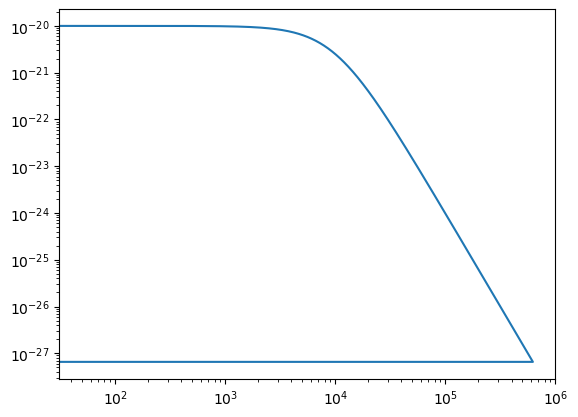

In [2]:
def power(f, f0, n, A0):
    return A0*A0 / (1 + (f/f0)**n)**2

fig, ax = plt.subplots()

psd = power(fdata, 1e4, 2, 1e-10)
psd[0] = 0


ax.plot(fdata, power(fdata, 1e4, 2, 1e-10))

ax.set_xscale('log')
ax.set_yscale('log')


noise = Noise()


noise.set_psd(channels = 'channel_00',
              psd = psd,
              psd_freqs=fdata,
              pretrigger_length_msec=pretrigger_length_sec*1000)



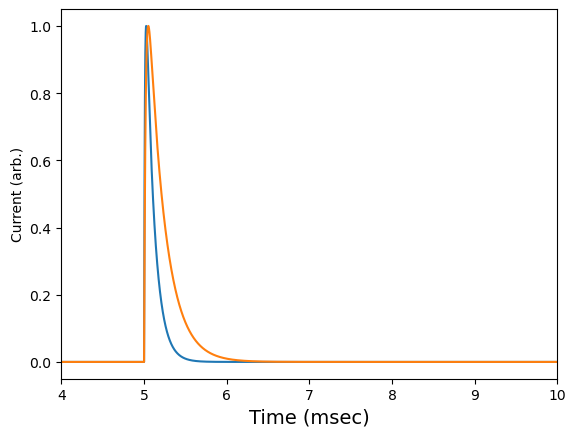

In [3]:
template = Template()

fig, ax = plt.subplots()

single_template = norm(twopole(tdata, 10e-6, 100e-6, 1, 5e-3))
share_template = norm(twopole(tdata, 20e-6, 200e-6, 1, 5e-3))

ax.plot(tdata*1000, single_template)
ax.plot(tdata*1000, share_template)

ax.set_xlim(4,10)
ax.set_xlabel('Time (msec)', fontsize = 14)
ax.set_ylabel('Current (arb.)')



template.set_template(channels = ['channel_00'],
                      template = single_template,
                      sample_rate = fs,
                      pretrigger_length_msec = pretrigger_length_sec*1000,
                      tag = 'single')


template.set_template(channels = ['channel_00'],
                      template = share_template,
                      sample_rate = fs,
                      pretrigger_length_msec = pretrigger_length_sec*1000,
                      tag = 'shared')


### dPdI

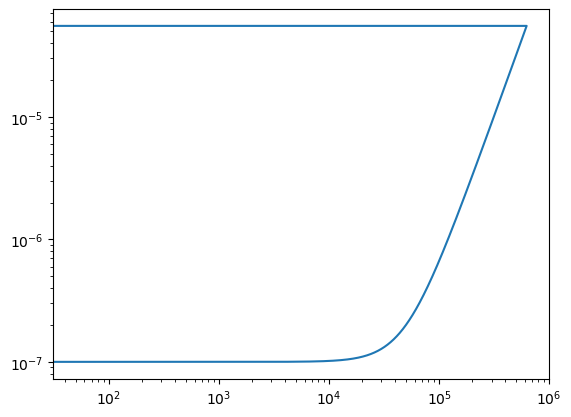

In [4]:
def dpdi(f, f0, n, A0):
    return A0 * (1 + (np.abs(f)/f0)**n)

fig, ax = plt.subplots()

dpdi_vals =  dpdi(fdata, 5e4, 2.5, 1e-7).astype(np.complex128)

ax.plot(fdata, dpdi_vals)
ax.set_yscale('log')
ax.set_xscale('log')

template.set_dpdi(channels = 'channel_00',
                  dpdi = dpdi_vals.astype(np.complex128),
                  dpdi_err = 0.1*dpdi_vals.astype(np.complex128),
                  dpdi_freqs = fdata,
                  poles = 3,
                  sample_rate = fs)




In [5]:
template.save_hdf5('1channel_ppd.hdf5', overwrite = True)
noise.save_hdf5('1channel_ppd.hdf5', overwrite = True)

INFO: Saving filter/TES data to file 1channel_ppd.hdf5! (overwrite=True)
INFO: Saving filter/TES data to file 1channel_ppd.hdf5! (overwrite=True)


In [6]:

def singles_rate(E):
    return np.where(E > 25, 0, (np.abs(E-25))**1.1)

def shared_rate(E):
    return np.where(E > 50, 0, (np.abs(E-50))**1.1)

distribution_dict = {}

distribution_dict['single'] = singles_rate
distribution_dict['shared'] = shared_rate

with open('LEE_distributions.pkl', 'wb') as f:
    cloudpickle.dump(distribution_dict, f)